<a href="https://colab.research.google.com/github/paolagarciaes-co/Plan/blob/main/notebook_SVM_hiperparametros_y_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos Supervisados: SVM paso a paso

**Objetivo del notebook**

En este cuaderno vamos a trabajar con **datos sintéticos (dummy)** para entender de forma muy visual cómo cambia un modelo SVM cuando movemos sus hiperparámetros.

Nos vamos a enfocar en:

- qué hace SVM de manera intuitiva,
- por qué es importante **escalar** las variables,
- cómo afecta cambiar **`C`**,
- cómo afecta cambiar el **kernel**,
- cómo afecta cambiar **`gamma`** cuando usamos kernel RBF,
- cómo hacer **cross validation** paso a paso,
- cómo hacer una pequeña búsqueda de hiperparámetros con `GridSearchCV`.

La idea no es solamente correr código, sino **interpretar** qué está pasando en cada experimento.

## 1. Recordatorio teórico corto

SVM busca una frontera de decisión que separe las clases con el **mayor margen posible**.

### Idea intuitiva
- Si las clases son separables, SVM busca una línea/curva/plano que las divida.
- No todos los puntos importan igual: los más importantes son los que quedan cerca de la frontera.  
  A esos puntos se les llama **vectores de soporte**.
- Cuando permitimos errores, aparece el hiperparámetro **`C`**.

### Rol de `C`
- **`C` pequeño**: el modelo tolera más errores, favorece un margen más amplio, suele ser más suave.
- **`C` grande**: el modelo castiga más los errores, intenta clasificar mejor el entrenamiento, y puede generar fronteras más ajustadas.

### Rol del kernel
El kernel le dice al modelo **cómo medir similitud** y si la frontera será:
- **lineal** (`kernel='linear'`),
- o **no lineal** (`kernel='rbf'`, por ejemplo).

### Rol de `gamma` en RBF
`gamma` controla qué tan local es la influencia de cada punto:
- **`gamma` pequeño**: fronteras más suaves y globales.
- **`gamma` grande**: fronteras más complejas y locales.

> En términos pedagógicos, `C` controla cuánto me esfuerzo por no equivocarme, y `gamma` controla qué tan ondulada o compleja puede volverse la frontera.

In [ ]:
# ============================================================
# 0. Librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)

## 2. Funciones de apoyo para visualizar

Estas funciones nos permitirán:
1. graficar los datos,
2. dibujar la frontera de decisión del modelo,
3. comparar visualmente qué pasa cuando cambiamos hiperparámetros.

En este notebook la visualización es clave, porque la meta del grupo es **ver el efecto** de los hiperparámetros.

In [ ]:
# ============================================================
# 1. Funciones auxiliares
# ============================================================
def plot_dataset(X, y, title="Datos"):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


def plot_decision_boundary(model, X, y, title="Frontera de decisión", highlight_support=False):
    # Definimos una malla sobre el espacio de entrada
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Predicción en cada punto de la malla
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, s=35)

    # Si el modelo es un SVC entrenado después del escalado directamente sobre X,
    # podemos resaltar los vectores de soporte.
    if highlight_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        plt.scatter(
            sv[:, 0], sv[:, 1],
            s=120, facecolors='none', linewidths=1.8,
            label="Vectores de soporte"
        )
        plt.legend()

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## 3. Primer dataset dummy: `make_moons`

Este dataset es muy útil porque **no es linealmente separable** de forma perfecta con una recta.

Eso lo hace ideal para mostrar:
- cuándo un kernel lineal se queda corto,
- cuándo un kernel RBF ayuda,
- cómo `C` y `gamma` cambian la frontera.

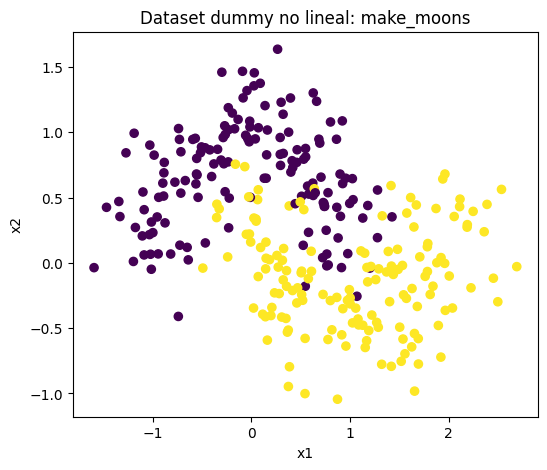

In [ ]:
# ============================================================
# 2. Dataset no lineal
# ============================================================
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

plot_dataset(X, y, title="Dataset dummy no lineal: make_moons")

## 4. Separación entrenamiento / prueba

Siempre dejamos un conjunto de prueba para evaluar el desempeño final.

Aunque aquí el énfasis principal es la **intuición visual**, mantenemos una práctica correcta de modelado:
- **train**: para ajustar el modelo,
- **test**: para revisar cómo generaliza.

In [ ]:
# ============================================================
# 3. Train-test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Tamaño train:", X_train.shape)
print("Tamaño test :", X_test.shape)

Tamaño train: (225, 2)
Tamaño test : (75, 2)


## 5. ¿Por qué escalamos antes de SVM?

SVM es sensible a la escala de las variables.  
Si una variable tiene valores mucho más grandes que otra, puede dominar el cálculo de distancias y la construcción de la frontera.

Por eso es buena práctica usar:
- `StandardScaler`
- dentro de un `Pipeline`

Así evitamos fugas de información y dejamos el flujo de trabajo bien organizado.

In [ ]:
# ============================================================
# 4. Pipeline base
# ============================================================
svm_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

svm_lineal.fit(X_train, y_train)

y_pred = svm_lineal.predict(X_test)

print("Accuracy en test:", round(accuracy_score(y_test, y_pred), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy en test: 0.8533

Matriz de confusión:
[[30  8]
 [ 3 34]]


## 6. Visualización del SVM lineal

Como el dataset tiene estructura curva, es normal que un SVM lineal no capture toda la forma.

### Preguntas para discutir en clase
1. ¿La frontera parece demasiado rígida?
2. ¿Qué errores deja?
3. ¿Qué tipo de patrón del dato no logra capturar?

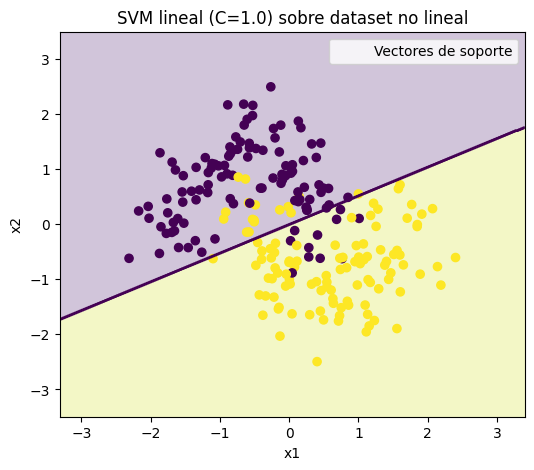

In [ ]:
# Para visualizar la frontera, entrenamos directamente sobre X escalado manualmente.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svc_linear_vis = SVC(kernel="linear", C=1.0)
svc_linear_vis.fit(X_train_scaled, y_train)

plot_decision_boundary(
    svc_linear_vis,
    X_train_scaled,
    y_train,
    title="SVM lineal (C=1.0) sobre dataset no lineal",
    highlight_support=True
)

## 7. Cambiando `C` en SVM lineal

Vamos a comparar tres escenarios:
- `C` pequeño,
- `C` intermedio,
- `C` grande.

### Qué deberíamos esperar
- Con **`C` pequeño**, la frontera tiende a ser más tolerante a errores.
- Con **`C` grande**, el modelo se vuelve más estricto con el entrenamiento.

C = 0.1
  Accuracy train: 0.8667
  Accuracy test : 0.8267


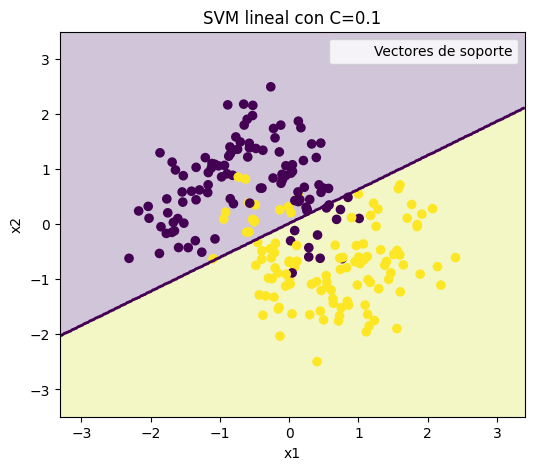

C = 1
  Accuracy train: 0.8800
  Accuracy test : 0.8533


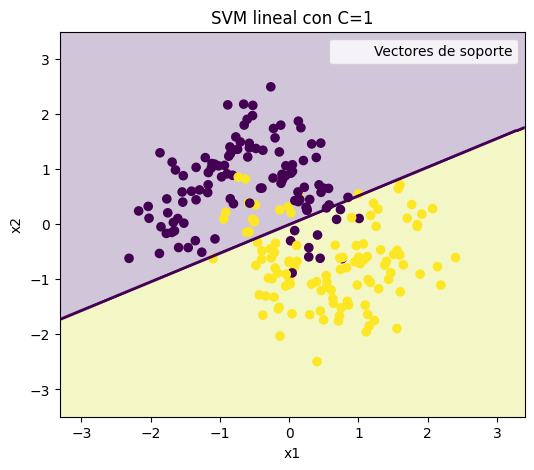

C = 100
  Accuracy train: 0.8800
  Accuracy test : 0.8267


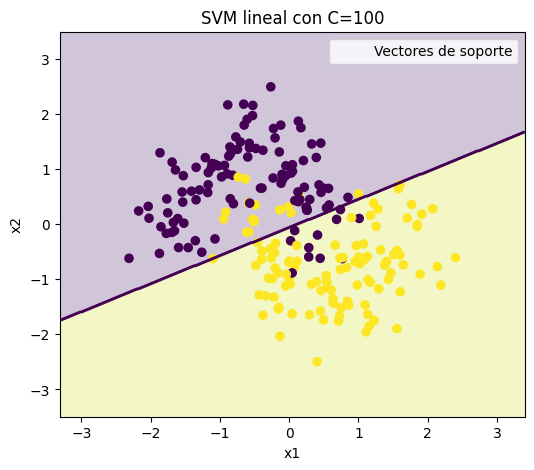

In [ ]:
# ============================================================
# 5. Efecto de C en SVM lineal
# ============================================================
C_values = [0.1, 1, 100]

for C in C_values:
    model = SVC(kernel="linear", C=C)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    print(f"C = {C}")
    print(f"  Accuracy train: {train_acc:.4f}")
    print(f"  Accuracy test : {test_acc:.4f}")

    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        title=f"SVM lineal con C={C}",
        highlight_support=True
    )

## 8. Pasemos a kernel RBF

Cuando la frontera real no es lineal, el kernel RBF suele ser una muy buena opción didáctica.

Aquí aparecen dos hiperparámetros importantes:
- **`C`**: penalización por errores,
- **`gamma`**: complejidad/localidad de la frontera.

In [ ]:
# ============================================================
# 6. SVM con kernel RBF
# ============================================================
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print("Accuracy en test (RBF):", round(accuracy_score(y_test, y_pred_rbf), 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rbf))

Accuracy en test (RBF): 0.8933

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89        38
           1       0.85      0.95      0.90        37

    accuracy                           0.89        75
   macro avg       0.90      0.89      0.89        75
weighted avg       0.90      0.89      0.89        75



## 9. Efecto de `gamma` en RBF

Ahora dejamos fijo `C` y movemos `gamma`.

### Interpretación
- **`gamma` pequeño**: cada punto influye a mayor distancia, frontera suave.
- **`gamma` grande**: cada punto influye localmente, frontera más ondulada.

Esto es excelente para mostrar en clase la diferencia entre:
- **subajuste**,
- **ajuste razonable**,
- **sobreajuste**.

gamma = 0.1
  Accuracy train: 0.8711
  Accuracy test : 0.8400


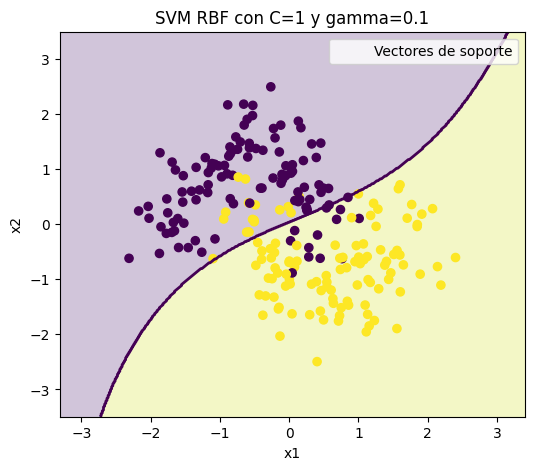

gamma = 1
  Accuracy train: 0.9156
  Accuracy test : 0.8933


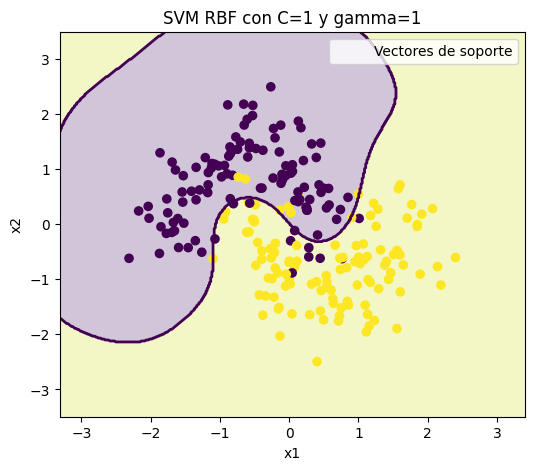

gamma = 10
  Accuracy train: 0.9600
  Accuracy test : 0.9200


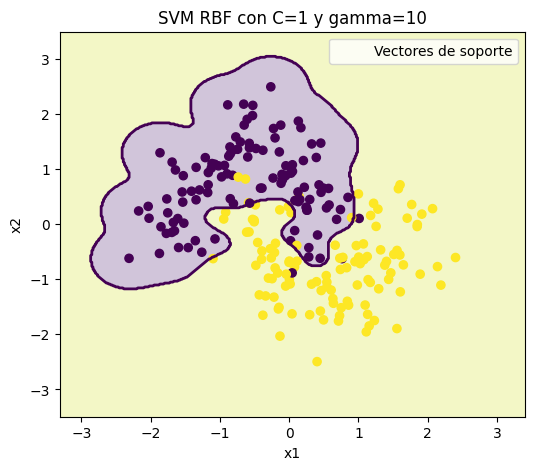

In [ ]:
# ============================================================
# 7. Efecto de gamma en RBF
# ============================================================
gamma_values = [0.1, 1, 10]

for gamma in gamma_values:
    model = SVC(kernel="rbf", C=1.0, gamma=gamma)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    print(f"gamma = {gamma}")
    print(f"  Accuracy train: {train_acc:.4f}")
    print(f"  Accuracy test : {test_acc:.4f}")

    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        title=f"SVM RBF con C=1 y gamma={gamma}",
        highlight_support=True
    )

## 10. Combinando `C` y `gamma`

Aquí está una de las lecciones más importantes del notebook:

No conviene estudiar hiperparámetros **aislados** todo el tiempo.  
A veces la calidad del modelo depende de la **combinación** entre ellos.

En clase vale la pena discutir:
- qué configuraciones parecen subajustadas,
- cuáles parecen razonables,
- cuáles parecen sobreajustadas.

C = 0.1, gamma = 0.1
  Accuracy train: 0.8667
  Accuracy test : 0.8267


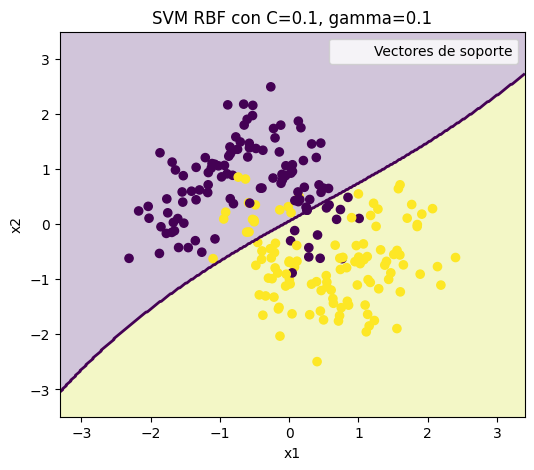

C = 1, gamma = 1
  Accuracy train: 0.9156
  Accuracy test : 0.8933


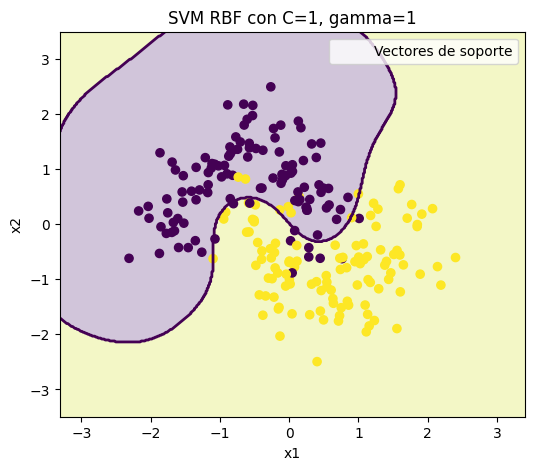

C = 100, gamma = 10
  Accuracy train: 0.9867
  Accuracy test : 0.8800


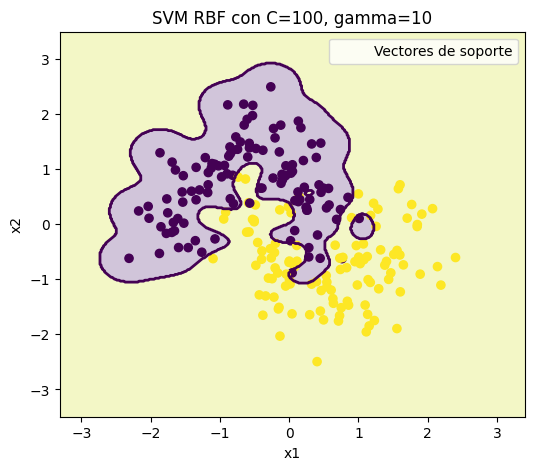

In [ ]:
# ============================================================
# 8. Combinación de C y gamma
# ============================================================
pairs = [
    (0.1, 0.1),
    (1, 1),
    (100, 10)
]

for C, gamma in pairs:
    model = SVC(kernel="rbf", C=C, gamma=gamma)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    print(f"C = {C}, gamma = {gamma}")
    print(f"  Accuracy train: {train_acc:.4f}")
    print(f"  Accuracy test : {test_acc:.4f}")

    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        title=f"SVM RBF con C={C}, gamma={gamma}",
        highlight_support=True
    )

## 11. Cross Validation paso a paso

Hasta ahora hemos usado un solo `train/test split`.  
Pero ese resultado depende de cómo cayó la partición.

Por eso usamos **cross validation**:

1. dividimos el conjunto de entrenamiento en varios pliegues,
2. entrenamos varias veces,
3. cada vez validamos en un pliegue distinto,
4. promediamos los resultados.

Eso nos da una estimación más estable del desempeño.

In [ ]:
# ============================================================
# 9. Cross validation paso a paso
# ============================================================
pipeline_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma=1.0))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Scores de cada fold:", np.round(scores, 4))
print("Promedio CV:", round(scores.mean(), 4))
print("Desviación estándar:", round(scores.std(), 4))

Scores de cada fold: [0.8222 0.9111 0.8667 0.8889 1.    ]
Promedio CV: 0.8978
Desviación estándar: 0.059


### ¿Cómo interpretar esto?

- Si los folds dan resultados parecidos, el modelo es más estable.
- Si los folds varían mucho, el modelo puede ser sensible al muestreo.
- El promedio de CV suele ser mejor guía que una sola partición.

> Para estudiantes principiantes, conviene explicar que CV es una manera de “no confiarse” de un único resultado.

## 12. Búsqueda de hiperparámetros con `GridSearchCV`

Ahora sí automatizamos la búsqueda.

La idea es:
1. definir una malla de valores para `C` y `gamma`,
2. evaluar cada combinación con cross validation,
3. escoger la mejor según una métrica.

In [ ]:
# ============================================================
# 10. GridSearchCV
# ============================================================
pipeline_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score promedio en CV:", round(grid.best_score_, 4))

Mejores hiperparámetros: {'svm__C': 1, 'svm__gamma': 10}
Mejor score promedio en CV: 0.9156


In [ ]:
# Resultados completos del grid
results = pd.DataFrame(grid.cv_results_)[[
    "param_svm__C",
    "param_svm__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

results.head(10)

,param_svm__C,param_svm__gamma,mean_test_score,std_test_score,rank_test_score
7,1.0,10.00,0.915556,0.016630,1
2,0.1,1.00,0.902222,0.033259,2
13,100.0,0.10,0.902222,0.045758,2
11,10.0,10.00,0.902222,0.045758,2
6,1.0,1.00,0.897778,0.033259,5
14,100.0,1.00,0.897778,0.030144,5
10,10.0,1.00,0.888889,0.024343,7
9,10.0,0.10,0.884444,0.055154,8
15,100.0,10.00,0.875556,0.022662,9
12,100.0,0.01,0.866667,0.042164,10


## 13. Evaluación final del mejor modelo en test

Solo después de usar cross validation para seleccionar hiperparámetros, revisamos el desempeño final en el conjunto de prueba.

In [ ]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)

print("Accuracy final en test:", round(accuracy_score(y_test, y_test_pred), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_test_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred))

Accuracy final en test: 0.92

Matriz de confusión:
[[33  5]
 [ 1 36]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92        38
           1       0.88      0.97      0.92        37

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75



## 14. Conclusiones

### Ideas clave
1. **SVM lineal** funciona bien cuando la frontera real es aproximadamente lineal.
2. **SVM con RBF** permite capturar relaciones no lineales.
3. **`C`** regula qué tan estricto es el modelo con los errores.
4. **`gamma`** regula qué tan compleja y local es la frontera.
5. **Cross validation** ayuda a seleccionar hiperparámetros de forma más confiable.

### Señales de alerta
- Accuracy de entrenamiento muy alta y test más baja: posible sobreajuste.
- Frontera demasiado compleja: posible sobreajuste.
- Frontera demasiado rígida: posible subajuste.

### Preguntas
- ¿Cuándo escogería kernel lineal y cuándo RBF?
- ¿Qué señales visuales sugieren que `gamma` está demasiado alto?
- ¿Qué pasa si `C` es muy bajo?
- ¿Por qué no deberíamos escoger hiperparámetros usando solo el conjunto de prueba?

## 15. Ejercicio propuesto

1. Cambie el dataset por uno generado con `make_classification`.
2. Compare kernel `linear`, `poly` y `rbf`.
3. Pruebe otro rango de `C` y `gamma`.
4. Use `scoring='f1'` en vez de `accuracy` si construye un dataset desbalanceado.
5. Escriba un párrafo interpretando qué configuración parece:
   - subajustada,
   - balanceada,
   - sobreajustada.